In [1]:
import os
import glob
import sys
import dill
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from yaml import safe_load, YAMLError, dump
from tabulate import tabulate
from scipy.interpolate import RectBivariateSpline
from scipy.stats import poisson, norm
from iminuit import Minuit

import config as cfg 
import post_bdtlh_efficiency_finder as eff_finder
plt.style.use('fcc.mplstyle')

In [2]:
def vars_fromyaml(path, bdtlist):
    with open(path) as stream:
        try:
            file = safe_load(stream)
            bdtvars = file[bdtlist]
        except YAMLError as exc:
            print(exc)
    return bdtvars

def set_outputpath(outputpath):
    if not os.path.exists(outputpath):
        os.makedirs(outputpath)
    return outputpath

In [3]:
import bdt_lh_cut_opt_with_n_interp as opt

In [4]:

def likelihood_model_builder(df, interp_N_dict, signal_BF=1e-6,
                             lrange_interp_N_dict=(0.995,1) ,hrange_interp_N_dict=(0.995,1),nlh=500,bins = (2,2),
                             ntoys = 250,
                             fit_plotpath=None, x_values = np.array([['A','B'],['C','D']]), spread_plotpath=None):

    """ 
    likelihood_model_builder(**opts ) will return optimum point from minimising signal error on fit to toys

    """

    _, S, B, S_err, B_err, signal_BF = opt.make_final_binning_plot(df, interp_N_dict, lrange_interp_N_dict=lrange_interp_N_dict ,hrange_interp_N_dict=hrange_interp_N_dict,signal_BF=signal_BF, nlh=nlh,eventsProcessed_dict = cfg.eventsProcessed , histbins=bins, components =  ['hadronic_background','combined_signal'], nMC_plots_path=None, final_plot_path = None)
    _, onebin_S, onebin_B, onebin_S_err, onebin_B_err, _ = opt.make_final_binning_plot(df, interp_N_dict, lrange_interp_N_dict=lrange_interp_N_dict ,hrange_interp_N_dict=hrange_interp_N_dict,signal_BF=signal_BF, nlh=nlh,eventsProcessed_dict = cfg.eventsProcessed , histbins=1, components =  ['hadronic_background','combined_signal'], nMC_plots_path=None, final_plot_path = None)
    poisson_expectation = B + S
    overall_background_error = onebin_B_err.item()/onebin_B.item()  #need fractional error as it propagates through on scale factor  
    #overall_background_error = np.max(B_err/B)
    if onebin_S.item() != 0:
        overall_sig_error = onebin_S_err.item()/onebin_S.item()

    
    ## define fit to toy (this is the negative log likelihood to minimize)
    def poisson_likelihood(sc_b, sc_s): #scale S and B separately, assuming know shape perfectly
        expectation = sc_b * B + sc_s * S # assumes know shape perfectly
        poiss_term = -np.sum( poisson.logpmf(toy_data, expectation)) #logpmf = Log of the probability mass function
        bkg_constraint_term = -norm.logpdf( sc_b, 1, overall_background_error)
        #include signal constraint term if S > 0
        if onebin_S.item() != 0:
            sig_constraint_term = -norm.logpdf( sc_s, 1, overall_sig_error)
            if n==0:
                print(f'fractional signal error={overall_sig_error}')
            return poiss_term + bkg_constraint_term+ sig_constraint_term
        else: 
            return poiss_term + bkg_constraint_term
    
    significance_arr=[]
    av_significance_for_bf = []
    stdev_significance_for_bf=[]

    # throw and refit toys
    for n in range(ntoys):
        toy_data = np.random.poisson(poisson_expectation) #throw toys
        mi = Minuit(poisson_likelihood, sc_b=1, sc_s=1 ) #fit toy
        mi.migrad()
        mi.hesse()
        sc_s = mi.values['sc_s']
        sc_b = mi.values['sc_b']
        sc_s_err = mi.errors['sc_s']
        sc_b_err = mi.errors['sc_b']

                                
        # refit with S=0 fixed for significance
        mi0 = Minuit(poisson_likelihood, sc_b=1, sc_s=0 )
        mi0.fixed['sc_s'] = True
        mi0.migrad()
        mi0.hesse()
        sc_s0 = mi0.values['sc_s']
        sc_b0 = mi0.values['sc_b']
           

        significance = np.sqrt(abs(2*(mi.fval-mi0.fval)))
        significance_arr.append(significance)  

        if fit_plotpath:
            if n ==0:
                print(f'fit sc_s = {sc_s}')
                print(f'fit sc_b = {sc_b}')
                x_strings =[x_values[1,0],x_values[0,0],x_values[0,1],x_values[1,1]] 
                x = np.arange(len(x_strings))
                plt.figure() 
                plt.bar(x,[sc_b*i for i in [B[1,0],B[0,0],B[0,1],B[1,1]]],label='Fit B', width=1.0, edgecolor='red', facecolor='none',hatch=r'\\\\')
                plt.bar(x,[sc_s *i for i in [S[1,0],S[0,0],S[0,1],S[1,1]]],label='Fit S', bottom=[sc_b*i for i in [B[1,0],B[0,0],B[0,1],B[1,1]]], width=1.0, edgecolor='royalblue',hatch='////', facecolor='none')
                plt.bar(x,[2*overall_background_error*sc_b*i for i in [B[1,0],B[0,0],B[0,1],B[1,1]]], bottom =np.subtract(np.add([sc_b *i for i in [B[1,0],B[0,0],B[0,1],B[1,1]]], [sc_s *i for i in [S[1,0],S[0,0],S[0,1],S[1,1]]]),[overall_background_error*sc_b*i for i in [B[1,0],B[0,0],B[0,1],B[1,1]]]), label='Gaussian constraint from \n error on generator B', color='black', alpha=0.4, width=1)
                plt.errorbar(x, [toy_data[1,0],toy_data[0,0],toy_data[0,1],toy_data[1,1]],yerr=[np.sqrt(i) for i in [toy_data[1,0],toy_data[0,0],toy_data[0,1],toy_data[1,1]]],xerr=0.5, fmt='.',label='Toy Data', color='k')
                plt.legend()
                plt.ylabel('Counts')
                plt.xticks(x, x_strings)
                plt.title(f'Example toy fit for signal BF = {signal_BF}')
                plt.savefig(os.path.join(set_outputpath(fit_plotpath),f'toy_fit_for_first_toy_BF{signal_BF}.pdf'))
    
    if spread_plotpath:
        plt.figure()        
        plt.title(f'Histogram of significance values over {ntoys} toys')
        plt.hist(significance_arr)
        plt.xlabel('Significance')
        plt.ylabel('Counts')
        plt.savefig(os.path.join(set_outputpath(fit_plotpath),f'histogram_of_all_toys_BF{signal_BF}.pdf'))
    
        
    significance_av = np.average(significance_arr)
    significance_stdev = np.std(significance_arr)    
    av_significance_for_bf.append(significance_av)
    stdev_significance_for_bf.append(significance_stdev)

    print(f'BF ={signal_BF}') 
    print(f'Average toy significance ={av_significance_for_bf}')   

    return av_significance_for_bf, stdev_significance_for_bf




In [5]:
   
#Load dataframe with bdtlh version applied
data={}
dir = cfg.fccana_opts["outputDir"]["prelim_cuts_full"]
folder = 'baseline_plus_bdtlh_dataframes/full_sample_medium_bdtlh_cut' 
for sample in cfg.samples:
    data[sample] = pd.read_pickle(os.path.join(dir,folder,f'{sample}.pkl'))

# Concatenate all DataFrames
full_data = pd.concat(data.values(), ignore_index=True)


#add extra rows so can work in range0.9-1
full_data['P_signal'] = full_data['bdt_score_2']
full_data['P_not_heavy'] = 1-full_data['bdt_score_1'] 
full_data['P_not_light'] = 1-full_data['bdt_score_0'] 

#add any extra cuts need here###########################
full_data = full_data.query('EVT_hemisEmax_n>10') #veto on taus

'''
N_dict, interp_N_dict, s_values_dict, eff_dict, err_dict = create_N_map(full_data,lrange=(0.995,1) ,hrange=(0.995,1),nlh=20, smoothing=False, kx=2, ky=2, save_path='/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/BDTlh_baseline_plus_cut_optimisation/with_tau_veto/no_smoothing/0995/')
plot_N(N_dict, interp_N_dict, lrange=(0.995,1) ,hrange=(0.995,1),nlh=20,slice=True, save_path='/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/plots/BDTlh_baseline_plus_cut_optimisation/with_tau_veto/')
'''

save_path='/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/BDTlh_baseline_plus_cut_optimisation/with_tau_veto/no_smoothing/0995/'

with open(os.path.join(set_outputpath(save_path), "interpolated_N_remaining_dictionary"), "rb") as dill_file:
    interp_N_dict = dill.load(dill_file)

with open(os.path.join(set_outputpath(save_path), "N_remaining_dictionary"), "rb") as dill_file:
    N_dict = dill.load(dill_file)


plotpath = '/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/plots/BDTlh_baseline_plus_cut_optimisation/with_tau_veto/no_smoothing/0995/optimisation/test'
#plot_interpolted_effs(interp_N_dict, N_dict ,nlh=20, slice=True, save_path=plotpath)
#FOM, err_FOM, S_arr, B_arr, S_error_arr, B_error_arr, lsearch, hsearch, sig_BF = run_2d_optimisation(interp_N_dict,lrange_plot=(0.995,1) ,hrange_plot=(0.995,1), nlh=500 , sig_BF=1e-7)
#plot_2d_optimisation(FOM, err_FOM, S_arr, B_arr, S_error_arr, B_error_arr, lsearch, hsearch, sig_BF, vmax=20,SB_plots = True, save_path=plotpath)

#per_sample_n_expect_dict, S, B, S_err, B_err, signal_BF  = make_final_binning_plot(full_data, interp_N_dict, signal_BF=1e-6, histbins=(2,2), nMC_plots_path=None, final_plot_path = None)
likelihood_model_builder(full_data, interp_N_dict, signal_BF=1e-7,
                         lrange_interp_N_dict=(0.995,1) ,hrange_interp_N_dict=(0.995,1),nlh=500,bins = (2,2),
                         ntoys = 250,
                         fit_plotpath=None, x_values = np.array([['A','B'],['C','D']]), spread_plotpath=None)


--> Finding optimum cut
Calculating S and B
+---------------+----------------------+----------------------+
|   Optimal FOM |   Optimal 1-P(l) cut |   Optimal 1-P(h) cut |
+===============+======================+======================+
|       18.2243 |               0.9997 |               0.9996 |
+---------------+----------------------+----------------------+
--> Finding number of events per bin
--> Finding optimum cut
Calculating S and B
+---------------+----------------------+----------------------+
|   Optimal FOM |   Optimal 1-P(l) cut |   Optimal 1-P(h) cut |
+===============+======================+======================+
|       18.2243 |               0.9997 |               0.9996 |
+---------------+----------------------+----------------------+
--> Finding number of events per bin
fractional signal error=0.00352649092551621
fractional signal error=0.00352649092551621
fractional signal error=0.00352649092551621
fractional signal error=0.00352649092551621
fractional signal erro

([283.65062773189237], [0.021479023226811788])

In [6]:
# Above with gaussian constraint on signal - just a total messsssss
np.sqrt(2*(norm.logpdf( 1, 1, 0.0035) -norm.logpdf( 0, 1, 0.0035)))

285.7142857142857

Difference in signal term from two fits accounting for discrepancy

## Fitting to gaussian to get accurate mu and sigma

In [10]:

def likelihood_model_builder(df, interp_N_dict, signal_BF=1e-6,
                             lrange_interp_N_dict=(0.995,1) ,hrange_interp_N_dict=(0.995,1),nlh=500,bins = (2,2),
                             ntoys = 250,
                             fit_plotpath=None, x_values = np.array([['A','B'],['C','D']]), spread_plotpath=None):

    """ 
    likelihood_model_builder(**opts ) will return optimum point from minimising signal error on fit to toys

    """

    _, S, B, S_err, B_err, signal_BF = opt.make_final_binning_plot(df, interp_N_dict, lrange_interp_N_dict=lrange_interp_N_dict ,hrange_interp_N_dict=hrange_interp_N_dict,signal_BF=signal_BF, nlh=nlh,eventsProcessed_dict = cfg.eventsProcessed , histbins=bins, components =  ['hadronic_background','combined_signal'], nMC_plots_path=None, final_plot_path = None)
    _, onebin_S, onebin_B, onebin_S_err, onebin_B_err, _ = opt.make_final_binning_plot(df, interp_N_dict, lrange_interp_N_dict=lrange_interp_N_dict ,hrange_interp_N_dict=hrange_interp_N_dict,signal_BF=signal_BF, nlh=nlh,eventsProcessed_dict = cfg.eventsProcessed , histbins=1, components =  ['hadronic_background','combined_signal'], nMC_plots_path=None, final_plot_path = None)
    poisson_expectation = B + S
    overall_background_error = onebin_B_err.item()/onebin_B.item()  #need fractional error as it propagates through on scale factor  
    #overall_background_error = np.max(B_err/B)
    print(f'S={S}')


    
    ## define fit to toy (this is the negative log likelihood to minimize)
    def poisson_likelihood(sc_b, sc_s): #scale S and B separately, assuming know shape perfectly
        expectation = sc_b * B + sc_s * S # assumes know shape perfectly
        poiss_term = -np.sum( poisson.logpmf(toy_data, expectation)) #logpmf = Log of the probability mass function
        bkg_constraint_term = -norm.logpdf( sc_b, 1, overall_background_error)

        return poiss_term + bkg_constraint_term
    
    significance_arr=[]
    av_significance_for_bf = []
    stdev_significance_for_bf=[]

    # throw and refit toys
    for n in range(ntoys):
        toy_data = np.random.poisson(poisson_expectation) #throw toys
        mi = Minuit(poisson_likelihood, sc_b=1, sc_s=0 ) #fit toy
        mi.migrad()
        mi.hesse()
        sc_s = mi.values['sc_s']
        sc_b = mi.values['sc_b']
        sc_s_err = mi.errors['sc_s']
        sc_b_err = mi.errors['sc_b']

                                
        # refit with S=0 fixed for significance
        mi0 = Minuit(poisson_likelihood, sc_b=1, sc_s=0 )
        mi0.fixed['sc_s'] = True
        mi0.migrad()
        mi0.hesse()
        sc_s0 = mi0.values['sc_s']
        sc_b0 = mi0.values['sc_b']
           

        significance = np.sqrt(abs(2*(mi.fval-mi0.fval)))
        significance_arr.append(significance)  

        if fit_plotpath:
            if n ==0:
                print(f'fit sc_s = {sc_s}')
                print(f'fit sc_b = {sc_b}')
                x_strings =[x_values[1,0],x_values[0,0],x_values[0,1],x_values[1,1]] 
                x = np.arange(len(x_strings))
                plt.figure() 
                plt.bar(x,[sc_b*i for i in [B[1,0],B[0,0],B[0,1],B[1,1]]],label='Fit B', width=1.0, edgecolor='red', facecolor='none',hatch=r'\\\\')
                plt.bar(x,[sc_s *i for i in [S[1,0],S[0,0],S[0,1],S[1,1]]],label='Fit S', bottom=[sc_b*i for i in [B[1,0],B[0,0],B[0,1],B[1,1]]], width=1.0, edgecolor='royalblue',hatch='////', facecolor='none')
                plt.bar(x,[2*overall_background_error*sc_b*i for i in [B[1,0],B[0,0],B[0,1],B[1,1]]], bottom =np.subtract(np.add([sc_b *i for i in [B[1,0],B[0,0],B[0,1],B[1,1]]], [sc_s *i for i in [S[1,0],S[0,0],S[0,1],S[1,1]]]),[overall_background_error*sc_b*i for i in [B[1,0],B[0,0],B[0,1],B[1,1]]]), label='Gaussian constraint from \n error on generator B', color='black', alpha=0.4, width=1)
                plt.errorbar(x, [toy_data[1,0],toy_data[0,0],toy_data[0,1],toy_data[1,1]],yerr=[np.sqrt(i) for i in [toy_data[1,0],toy_data[0,0],toy_data[0,1],toy_data[1,1]]],xerr=0.5, fmt='.',label='Toy Data', color='k')
                plt.legend()
                plt.ylabel('Counts')
                plt.xticks(x, x_strings)
                plt.title(f'Example toy fit for signal BF = {signal_BF}')
                plt.savefig(os.path.join(set_outputpath(fit_plotpath),f'toy_fit_for_first_toy_BF{signal_BF}.pdf'))
    
    if spread_plotpath:
        plt.figure()        
        plt.title(f'Histogram of significance values over {ntoys} toys')
        plt.hist(significance_arr)
        plt.xlabel('Significance')
        plt.ylabel('Counts')
        plt.savefig(os.path.join(set_outputpath(fit_plotpath),f'histogram_of_all_toys_BF{signal_BF}.pdf'))

        
    significance_av = np.average(significance_arr)
    significance_stdev = np.std(significance_arr)    
    av_significance_for_bf.append(significance_av)
    stdev_significance_for_bf.append(significance_stdev)

    print(f'BF ={signal_BF}') 
    print(f'Average toy significance ={av_significance_for_bf}')   

    return significance_arr, av_significance_for_bf, stdev_significance_for_bf




In [22]:
#Load dataframe with bdtlh version applied
data={}
dir = cfg.fccana_opts["outputDir"]["prelim_cuts_full"]
folder = 'baseline_plus_bdtlh_dataframes/full_sample_medium_bdtlh_cut' 
for sample in cfg.samples:
    data[sample] = pd.read_pickle(os.path.join(dir,folder,f'{sample}.pkl'))

# Concatenate all DataFrames
full_data = pd.concat(data.values(), ignore_index=True)


#add extra rows so can work in range0.9-1
full_data['P_signal'] = full_data['bdt_score_2']
full_data['P_not_heavy'] = 1-full_data['bdt_score_1'] 
full_data['P_not_light'] = 1-full_data['bdt_score_0'] 

#add any extra cuts need here###########################
full_data = full_data.query('EVT_hemisEmax_n>10') #veto on taus

'''
N_dict, interp_N_dict, s_values_dict, eff_dict, err_dict = create_N_map(full_data,lrange=(0.995,1) ,hrange=(0.995,1),nlh=20, smoothing=False, kx=2, ky=2, save_path='/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/BDTlh_baseline_plus_cut_optimisation/with_tau_veto/no_smoothing/0995/')
plot_N(N_dict, interp_N_dict, lrange=(0.995,1) ,hrange=(0.995,1),nlh=20,slice=True, save_path='/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/plots/BDTlh_baseline_plus_cut_optimisation/with_tau_veto/')
'''

save_path='/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/BDTlh_baseline_plus_cut_optimisation/with_tau_veto/no_smoothing/0995/'

with open(os.path.join(set_outputpath(save_path), "interpolated_N_remaining_dictionary"), "rb") as dill_file:
    interp_N_dict = dill.load(dill_file)

with open(os.path.join(set_outputpath(save_path), "N_remaining_dictionary"), "rb") as dill_file:
    N_dict = dill.load(dill_file)


plotpath = '/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/plots/BDTlh_baseline_plus_cut_optimisation/with_tau_veto/no_smoothing/0995/optimisation/test'

significance, av_significance_for_bf, stdev_significance_for_bf = likelihood_model_builder(full_data, interp_N_dict, signal_BF=1e-7,
                         lrange_interp_N_dict=(0.995,1) ,hrange_interp_N_dict=(0.995,1),nlh=500,bins = (2,2),
                         ntoys = 10000,
                         fit_plotpath=None, x_values = np.array([['A','B'],['C','D']]), spread_plotpath=None)


--> Finding optimum cut
Calculating S and B
+---------------+----------------------+----------------------+
|   Optimal FOM |   Optimal 1-P(l) cut |   Optimal 1-P(h) cut |
+===============+======================+======================+
|       18.2243 |               0.9997 |               0.9996 |
+---------------+----------------------+----------------------+
--> Finding number of events per bin
--> Finding optimum cut
Calculating S and B
+---------------+----------------------+----------------------+
|   Optimal FOM |   Optimal 1-P(l) cut |   Optimal 1-P(h) cut |
+===============+======================+======================+
|       18.2243 |               0.9997 |               0.9996 |
+---------------+----------------------+----------------------+
--> Finding number of events per bin
S=[[1905.31305216 4117.56587607]
 [1565.39913356 9319.47390039]]
BF =1e-07
Average toy significance =[6.84969850543162]


In [23]:
import numpy as np
from numba_stats import norm, expon
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit.cost import ExtendedUnbinnedNLL, ExtendedBinnedNLL
import joblib

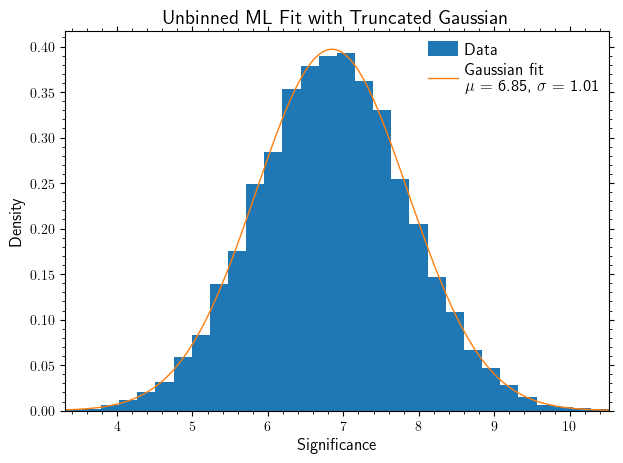

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.422e+04                  │              Nfcn = 32               │
│ EDM = 2.04e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ mu    │   6.849   │   0.014   │            │            │         │         │       │
│ 1 │ sigma │   1.005   │   0.010   │            │            │  0.001  │         │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬───────────────────┐
│       │       mu    sigma │
├───────┼───────────────────┤
│    mu │ 0.000203       -0 │
│ sigma │       -0 0.000104 │
└───────┴───────────────────┘

In [26]:
# Example unbinned data
data = np.array(significance)

# Truncation limits
lower, upper = data.min(), data.max()

# Truncated Gaussian log-likelihood
def truncated_logpdf(x, mu, sigma):
    norm_const = norm.cdf(upper, mu, sigma) - norm.cdf(lower, mu, sigma)
    return norm.logpdf(x, mu, sigma) - np.log(norm_const)

# Negative log-likelihood
def nll(mu, sigma):
    if sigma <= 0:
        return np.inf
    return -np.sum(truncated_logpdf(data, mu, sigma))

# Initial parameter guesses
mu_init = np.mean(data)
sigma_init = np.std(data)

# Fit using iminuit
m = Minuit(nll, mu=mu_init, sigma=sigma_init)
m.limits["sigma"] = (1e-3, None)
m.migrad()
m.hesse()

fitted_mu = m.values['mu']
fitted_sigma = m.values['sigma']

# Plot
fig, ax = plt.subplots()
counts, bins, _ = ax.hist(data, bins=30, density=True, label="Data")

# Evaluate PDF for plotting
x_vals = np.linspace(lower, upper, 1000)
norm_const = norm.cdf(upper, fitted_mu, fitted_sigma) - norm.cdf(lower, fitted_mu, fitted_sigma)
pdf_vals = norm.pdf(x_vals, fitted_mu, fitted_sigma) / norm_const

ax.plot(x_vals, pdf_vals, label=f'Gaussian fit\n$\mu$ = {fitted_mu:.2f}, $\sigma$ = {fitted_sigma:.2f}')
ax.set_xlabel("Significance")
ax.set_ylabel("Density")
ax.set_title("Unbinned ML Fit with Truncated Gaussian")
ax.legend()
plt.tight_layout()
plt.show()
m

Fitted mu = 0.809 ± 0.009
Fitted sigma = 0.610 ± 0.006


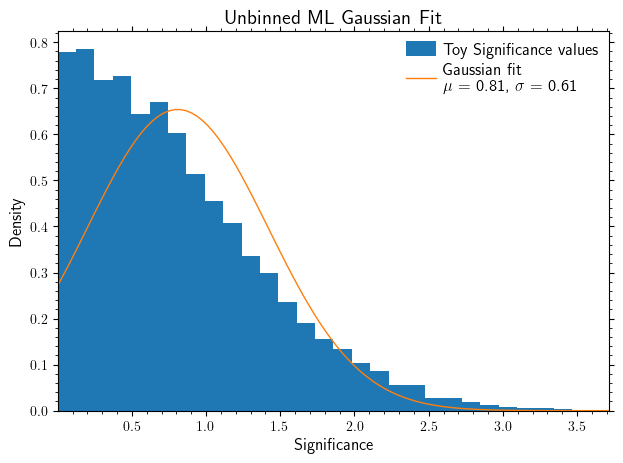

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 9245                       │              Nfcn = 70               │
│ EDM = 4.81e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ mu    │   0.809   │   0.009   │            │            │         │         │       │
│ 1 │ sigma │   0.610   │   0.006   │            │            │    0    │         │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬───────────────────┐
│       │       mu    sigma │
├───────┼───────────────────┤
│    mu │ 7.44e-05        0 │
│ sigma │        0 3.72e-05 │
└───────┴───────────────────┘

In [21]:
'''
data = np.array(significance)

# Normalized unbinned likelihood for Gaussian
def unbinned_nll(mu, sigma):
    if sigma <= 0:
        return np.inf
    log_probs = norm.logpdf(data, loc=mu, scale=sigma)
    return -np.sum(log_probs)

# Initial guesses
mu_init = np.mean(data)
sigma_init = np.std(data)

# Minuit minimization
m = Minuit(unbinned_nll, mu=0, sigma=1)
m.limits["sigma"] = (0, None)
m.limits["mu"] = (None, None)
m.migrad()
m.hesse()

# Results
mu_fit = m.values['mu']
sigma_fit = m.values['sigma']
mu_err = m.errors['mu']
sigma_err = m.errors['sigma']

print(f"Fitted mu = {mu_fit:.3f} ± {mu_err:.3f}")
print(f"Fitted sigma = {sigma_fit:.3f} ± {sigma_err:.3f}")


x = np.linspace(min(data), max(data), 100)
pdf_vals = norm.pdf(x, loc=mu_fit, scale=sigma_fit)

plt.figure()
plt.hist(data, bins=30, density=True, label='Toy Significance values')
plt.plot(x, pdf_vals, label=f'Gaussian fit\n$\mu$ = {mu_fit:.2f}, $\sigma$ = {sigma_fit:.2f}')
plt.xlabel('Significance')
plt.ylabel('Density')
plt.legend()
plt.title('Unbinned ML Gaussian Fit')
plt.show()
m
'''